In [88]:
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy as sts

<h4>Часть I.

В таблице (см. файл lab_4_DATA_2024.xls) содержатся данные о работниках: ЗАРПЛАТА,
СТАЖ РАБОТЫ, ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ, и ПОЛ РАБОТНИКА.
Выберите из файла lab_4_DATA_2024.xls данные 515 наблюдений, где объем выборки 515
приведен в таблице ВАРИАНТЫ ЗАДАНИЙ.
Далее следует оценивать модели по выборке из n наблюдений.
1. Найдите оценки параметров линейной модели зависимости ЗАРПЛАТЫ от фактора ВРЕМЯ, ЗАТРАЧЕННОЕ НА
ОБРАЗОВАНИЕ (лет).

In [89]:
df=pd.read_excel("LAB_4_DATA_2024.xlsx")
df= df.drop(["СТАЖ РАБОТЫ (лет)", "ПОЛ (1-жен, 0- муж)" ], axis=1)
df = df.drop(labels=range(517, 540), axis=0)
df

,"ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ (лет)",Зарплата (долл. в час)
0,12,53.410000
1,12,8.000000
2,15,24.000000
3,13,29.500000
4,18,32.049999
...,...,...
512,12,9.250000
513,12,13.000000
514,16,16.180000
515,18,12.000000


In [90]:

X=sm.add_constant(df["ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ (лет)"])
model = sm.OLS(df["Зарплата (долл. в час)"], X).fit() 
summary=model.summary()
coef_vremya = model.params[1] 
std_err_vremya = model.bse[1] 
summary

C:\Users\veron\AppData\Local\Temp\ipykernel_476\285857579.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef_vremya = model.params[1]
C:\Users\veron\AppData\Local\Temp\ipykernel_476\285857579.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  std_err_vremya = model.bse[1]


<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     Зарплата (долл. в час)   R-squared:                       0.173
Model:                                OLS   Adj. R-squared:                  0.171
Method:                     Least Squares   F-statistic:                     107.4
Date:                    Thu, 05 Dec 2024   Prob (F-statistic):           5.48e-23
Time:                            17:44:39   Log-Likelihood:                -2072.2
No. Observations:                     517   AIC:                             4148.
Df Residuals:                         515   BIC:                             4157.
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
===========================================================================================================
                                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
const                                     -13.9537      3.310     -4.215      0.000     -20.457      -7.451
ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ (лет)     2.4662      0.238     10.364      0.000       1.999       2.934
==============================================================================
Omnibus:                      372.005   Durbin-Watson:                   1.759
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5651.508
Skew:                           3.010   Prob(JB):                         0.00
Kurtosis:                      18.037   Cond. No.                         78.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**R-squared (uncentered)**:
0.173 — это коэффициент детерминации, который показывает, что примерно 17.3% вариации зарплаты объясняется временем, затраченным на образование. Это значение указывает на хорошую подгонку модели.

**Adj. R-squared (uncentered)**:
0.171 — скорректированный коэффициент детерминации, который учитывает количество предикторов в модели. Он немного ниже, что нормально для моделей с одним предиктором.

**F-statistic:**
107.4 — используется для тестирования значимости всей модели. Высокое значение указывает на то, что модель в целом хорошо объясняет данные.

5.48e-23 — это p-значение для F-статистики. Значение близкое к нулю указывает на то, что модель статистически значима.

**Коэффициенты модели**
**coef:**

**ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ (лет)**: 2.4662 — это оценка коэффициента для переменной "время". Это означает, что при увеличении времени на образование на 1 год, зарплата увеличивается в среднем на 2.4662 долларов в час. ( 5 пункт л/р)

**std err**:

0.238 — стандартная ошибка коэффициента. Она показывает, насколько точно оценен коэффициент. Меньшие значения указывают на более надежные оценки.

**t:**

10.364 — t-статистика для проверки значимости коэффициента. Значение значительно больше 2 указывает на то, что коэффициент статистически значим.

**P>|t|**:

0.000 — p-значение для проверки нулевой гипотезы о том, что коэффициент равен нулю. Значение меньше 0.05 указывает на то, что мы можем отвергнуть нулевую гипотезу и считать коэффициент значимым. В данном случае это означает, что время, затраченное на учебу, в значительной степени влияет на зарплату.

**[0.025, 0.975]**:

[ 1.999 2.934] — 95% доверительный интервал для коэффициента. Это диапазон значений, в котором мы можем ожидать истинное значение коэффициента с 95% вероятностью.

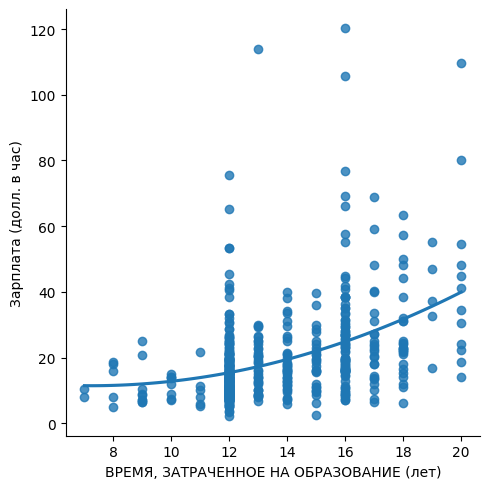

In [91]:
sns.lmplot(x = "ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ (лет)", y = "Зарплата (долл. в час)", data = df, order = 2, ci = None)

2. Проверьте на уровне значимости 0,04, обладает ли построенная модель высокой
объясняющей способностью, или же модель низкого качества.

In [92]:
alpha = 0.04  # Уровень значимости

r_squared = model.rsquared
f_p_value = model.f_pvalue
# Проверяем объясняющую способность
if r_squared < 0.1:
    print("Модель обладает низкой объясняющей способностью.")
if 0.1<= r_squared < 0.4:
    print("Модель обладает умеренной объясняющей способностью.")
if r_squared >= 0.4:
    print("Модель обладает высокой объясняющей способностью.")

# Проверяем значимость модели
if f_p_value < alpha:
    print("Модель статистически значима на уровне значимости 0.04.")
else:
    print("Модель не статистически значима на уровне значимости 0.04.")


print(f"R-squared: {r_squared}")
print(f"p_value {f_p_value}")


Модель обладает умеренной объясняющей способностью.
Модель статистически значима на уровне значимости 0.04.
R-squared: 0.17257442245284194
p_value 5.47773856872176e-23


3. Найдите оценки параметров линейной модели зависимости ЗАРПЛАТЫ от СТАЖА
РАБОТЫ и ВРЕМЕНИ, ЗАТРАЧЕННОГО НА ОБРАЗОВАНИЕ.

In [93]:
df_new=pd.read_excel("LAB_4_DATA_2024.xlsx")
df_new= df_new.drop(["ПОЛ (1-жен, 0- муж)" ], axis=1)
df_new = df_new.drop(labels=range(517, 540), axis=0)
df_new

,СТАЖ РАБОТЫ (лет),"ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ (лет)",Зарплата (долл. в час)
0,22.384615,12,53.410000
1,8.903846,12,8.000000
2,13.250000,15,24.000000
3,18.250000,13,29.500000
4,13.769231,18,32.049999
...,...,...,...
512,6.153846,12,9.250000
513,20.903847,12,13.000000
514,18.076923,16,16.180000
515,7.884615,18,12.000000


In [94]:

X=sm.add_constant(df_new[["ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ (лет)","СТАЖ РАБОТЫ (лет)"]])
model_2 = sm.OLS(df_new['Зарплата (долл. в час)'], X).fit()
summary_2=model_2.summary()
summary_2

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     Зарплата (долл. в час)   R-squared:                       0.203
Model:                                OLS   Adj. R-squared:                  0.200
Method:                     Least Squares   F-statistic:                     65.56
Date:                    Thu, 05 Dec 2024   Prob (F-statistic):           4.37e-26
Time:                            17:44:40   Log-Likelihood:                -2062.4
No. Observations:                     517   AIC:                             4131.
Df Residuals:                         514   BIC:                             4144.
Df Model:                               2                                         
Covariance Type:                nonrobust                                         
===========================================================================================================
                                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
const                                     -27.3072      4.425     -6.171      0.000     -36.001     -18.613
ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ (лет)     2.7075      0.240     11.284      0.000       2.236       3.179
СТАЖ РАБОТЫ (лет)                           0.5945      0.134      4.448      0.000       0.332       0.857
==============================================================================
Omnibus:                      370.595   Durbin-Watson:                   1.807
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5580.670
Skew:                           2.997   Prob(JB):                         0.00
Kurtosis:                      17.938   Cond. No.                         169.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

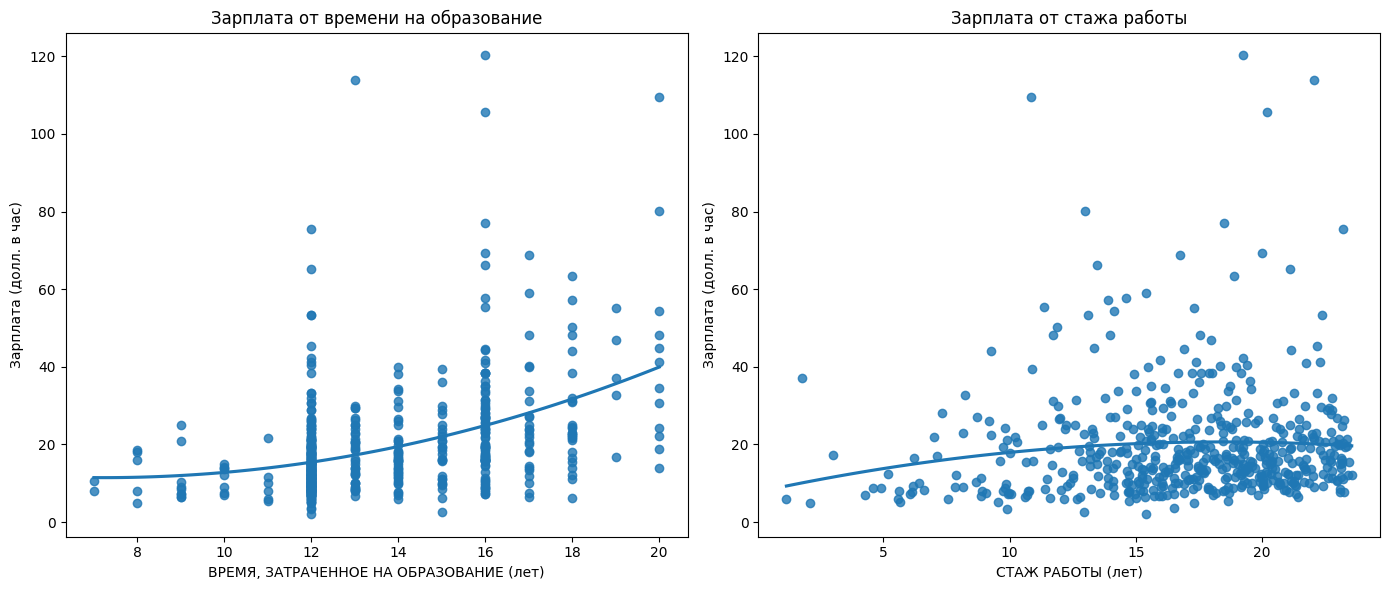

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Первый график
sns.regplot(x="ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ (лет)", 
            y="Зарплата (долл. в час)", 
            data=df_new, 
            order=2, 
            ci=None, 
            ax=axes[0])
axes[0].set_title('Зарплата от времени на образование')

# Второй график
sns.regplot(x="СТАЖ РАБОТЫ (лет)", 
            y="Зарплата (долл. в час)", 
            data=df_new, 
            order=2, 
            ci=None, 
            ax=axes[1])
axes[1].set_title('Зарплата от стажа работы')

# Настройка общего отображения
plt.tight_layout()
plt.show()

4. На сколько в среднем изменится ЗАРПЛАТА, если СТАЖ РАБОТЫ увеличить на 1 год,
а ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ, останется неизменным?

In [96]:
X=sm.add_constant(df_new["СТАЖ РАБОТЫ (лет)"])
model = sm.OLS(df_new["Зарплата (долл. в час)"], X).fit() 
summary_3=model.summary()
coef_staz_raboty = model.params[1] 
std_err_staz_raboty = model.bse[1] 
print(coef_staz_raboty)
print(std_err_staz_raboty)
summary_3

0.25346987734175425
0.14528144857779918


C:\Users\veron\AppData\Local\Temp\ipykernel_476\3008010262.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef_staz_raboty = model.params[1]
C:\Users\veron\AppData\Local\Temp\ipykernel_476\3008010262.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  std_err_staz_raboty = model.bse[1]


<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     Зарплата (долл. в час)   R-squared:                       0.006
Model:                                OLS   Adj. R-squared:                  0.004
Method:                     Least Squares   F-statistic:                     3.044
Date:                    Thu, 05 Dec 2024   Prob (F-statistic):             0.0816
Time:                            17:44:40   Log-Likelihood:                -2119.6
No. Observations:                     517   AIC:                             4243.
Df Residuals:                         515   BIC:                             4252.
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                15.5249      2.539      6.116      0.000      10.538      20.512
СТАЖ РАБОТЫ (лет)     0.2535      0.145      1.745      0.082      -0.032       0.539
==============================================================================
Omnibus:                      362.647   Durbin-Watson:                   1.818
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4479.610
Skew:                           2.994   Prob(JB):                         0.00
Kurtosis:                      16.118   Cond. No.                         69.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**coef:**: 0.2535 — это оценка коэффициента для переменной "стаж". Это означает, что при увеличении времени на образование на 1 год, зарплата увеличивается в среднем на 0,25 долларов в час.

6. Проверьте на уровне значимости , обладает ли построенная двухфакторная модель
высокой объясняющей способностью, или же модель низкого качества.

In [97]:
alpha = 0.04  # Уровень значимости

r_squared = model.rsquared
f_p_value = model.f_pvalue
# Проверяем объясняющую способность
if r_squared < 0.1:
    print("Модель обладает низкой объясняющей способностью.")
if 0.1<= r_squared < 0.4:
    print("Модель обладает умеренной объясняющей способностью.")
if r_squared >= 0.4:
    print("Модель обладает высокой объясняющей способностью.")

# Проверяем значимость модели
if f_p_value < alpha:
    print("Модель статистически значима на уровне значимости 0.04.")
else:
    print("Модель не статистически значима на уровне значимости 0.04.")


print(f"R-squared: {r_squared}")
print(f"p_value {f_p_value}")

Модель обладает низкой объясняющей способностью.
Модель не статистически значима на уровне значимости 0.04.
R-squared: 0.005875783838757975
p_value 0.08163682016853731


6. Проверьте на уровне значимости 0,04, обладает ли построенная двухфакторная модель
высокой объясняющей способностью, или же модель низкого качества.

In [98]:
r_squared = model_2.rsquared
f_p_value = model_2.f_pvalue
# Проверяем объясняющую способность
if r_squared < 0.1:
    print("Модель обладает низкой объясняющей способностью.")
if 0.1<= r_squared < 0.4:
    print("Модель обладает умеренной объясняющей способностью.")
if r_squared >= 0.4:
    print("Модель обладает высокой объясняющей способностью.")

# Проверяем значимость модели
if f_p_value < alpha:
    print("Модель статистически значима на уровне значимости 0.04.")
else:
    print("Модель не статистически значима на уровне значимости 0.04.")


print(f"R-squared: {r_squared}")
print(f"p_value {f_p_value}")

Модель обладает умеренной объясняющей способностью.
Модель статистически значима на уровне значимости 0.04.
R-squared: 0.20324544785658172
p_value 4.3692835744492635e-26


7. С надежностью 0,96 постройте доверительные интервалы для теоретических
коэффициентов регрессии модели.

In [99]:
coefficients = model_2.params
standard_errors = model_2.bse

# Определение уровня надежности
confidence_level = 0.96
alpha = 1 - confidence_level

# Вычисление критического значения t
t_critical = sts.stats.t.ppf(1 - alpha/2, model_2.df_resid)

# Вычисление доверительных интервалов
lower_bounds = coefficients - t_critical * standard_errors
upper_bounds = coefficients + t_critical * standard_errors

# Создание DataFrame для результатов
conf_intervals = pd.DataFrame({
    'Нижний предел': lower_bounds,
    'Верхний предел': upper_bounds,
    'Коэффициенты': coefficients,
})

print(conf_intervals)

                                         Нижний предел  Верхний предел  \
const                                       -36.418801      -18.195539   
ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ (лет)       2.213483        3.201567   
СТАЖ РАБОТЫ (лет)                             0.319321        0.869690   

                                         Коэффициенты  
const                                      -27.307170  
ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ (лет)      2.707525  
СТАЖ РАБОТЫ (лет)                            0.594505  


<h4>Часть II.

1. Найдите оценки параметров линейной модели зависимости ЗАРПЛАТЫ от СТАЖА
РАБОТЫ, ВРЕМЕНИ, ЗАТРАЧЕННОГО НА ОБРАЗОВАНИЕ, и ПОЛА РАБОТНИКА.

In [100]:
df_2=pd.read_excel("LAB_4_DATA_2024.xlsx")
#df_2 = df_2.drop(labels=range(517, 540), axis=0)
df_2

,СТАЖ РАБОТЫ (лет),"ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ (лет)","ПОЛ (1-жен, 0- муж)",Зарплата (долл. в час)
0,22.384615,12,0,53.410000
1,8.903846,12,0,8.000000
2,13.250000,15,0,24.000000
3,18.250000,13,0,29.500000
4,13.769231,18,0,32.049999
...,...,...,...,...
535,7.307693,12,1,9.500000
536,19.288462,14,1,17.299999
537,21.230770,12,1,27.520000
538,18.076923,13,1,3.880000


In [101]:
X=sm.add_constant(df_2[["ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ (лет)","СТАЖ РАБОТЫ (лет)", "ПОЛ (1-жен, 0- муж)"]])
model_4 = sm.OLS(df_2['Зарплата (долл. в час)'], X).fit()
summary_4=model_4.summary()
summary_4

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     Зарплата (долл. в час)   R-squared:                       0.241
Model:                                OLS   Adj. R-squared:                  0.237
Method:                     Least Squares   F-statistic:                     56.68
Date:                    Thu, 05 Dec 2024   Prob (F-statistic):           7.74e-32
Time:                            17:44:40   Log-Likelihood:                -2132.2
No. Observations:                     540   AIC:                             4272.
Df Residuals:                         536   BIC:                             4290.
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
===========================================================================================================
                                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
const                                     -19.6919      4.361     -4.516      0.000     -28.258     -11.126
ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ (лет)     2.5911      0.229     11.337      0.000       2.142       3.040
СТАЖ РАБОТЫ (лет)                           0.4057      0.129      3.149      0.002       0.153       0.659
ПОЛ (1-жен, 0- муж)                        -5.9091      1.114     -5.304      0.000      -8.097      -3.721
==============================================================================
Omnibus:                      404.752   Durbin-Watson:                   1.896
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7226.889
Skew:                           3.140   Prob(JB):                         0.00
Kurtosis:                      19.785   Cond. No.                         178.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

2. Проверьте на уровне значимости 0,04, обладает ли построенная трехфакторная модель
высокой объясняющей способностью, или же эта модель низкого качества.

In [102]:
r_squared = model_4.rsquared
f_p_value = model_4.f_pvalue
# Проверяем объясняющую способность
if r_squared < 0.1:
    print("Модель обладает низкой объясняющей способностью.")
if 0.1<= r_squared < 0.4:
    print("Модель обладает умеренной объясняющей способностью.")
if r_squared >= 0.4:
    print("Модель обладает высокой объясняющей способностью.")

# Проверяем значимость модели
if f_p_value < alpha:
    print("Модель статистически значима на уровне значимости 0.04.")
else:
    print("Модель не статистически значима на уровне значимости 0.04.")


print(f"R-squared: {r_squared}")
print(f"p_value {f_p_value}")

Модель обладает умеренной объясняющей способностью.
Модель статистически значима на уровне значимости 0.04.
R-squared: 0.2408483676272989
p_value 7.736950333450648e-32


3.Существенно ли на уровне значимости 0,04 различаются зарплаты мужчины и женщины
при прочих равных условиях (т.е. равных стаже и числу лет, затраченных на образование)?

Тогда
H0: a_w=a_m
H1: a_w!=a_m


In [117]:
men_salary=df_2[df_2['ПОЛ (1-жен, 0- муж)'] ==0]
men_salary
men_salary.to_csv("file_name", sep='\t', encoding='utf-8')

In [104]:
women_salary=df_2[df_2['ПОЛ (1-жен, 0- муж)'] ==1]
women_salary

,СТАЖ РАБОТЫ (лет),"ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ (лет)","ПОЛ (1-жен, 0- муж)",Зарплата (долл. в час)
270,13.557693,16,1,17.620001
271,18.461538,14,1,21.000000
272,22.884615,12,1,19.500000
273,22.480770,13,1,20.620001
274,14.634615,15,1,25.000000
...,...,...,...,...
535,7.307693,12,1,9.500000
536,19.288462,14,1,17.299999
537,21.230770,12,1,27.520000
538,18.076923,13,1,3.880000


In [105]:
stat, p = sts.stats.ttest_ind(men_salary["Зарплата (долл. в час)"], women_salary["Зарплата (долл. в час)"], equal_var=False)
print(f"Статистика: {stat}")
print(f"p-значение: {p}")
if p < alpha:
    print(f'Средние значения зарплат значимо отличаются\n')
else:
    print(f'Средние значения зарплат не отличаются\n')

Статистика: 5.772590586018279
p-значение: 1.3871444257374468e-08
Средние значения зарплат значимо отличаются



6. Проверьте на уровне значимости 0,04, отражает ли полученное при оценке регрессии
значение коэффициента при факторе СТАЖ РАБОТЫ истинную зависимость, или же оно
появилось случайно?

In [106]:
coef_staz_raboty #коэф-нт
std_err_staz_raboty 
alpha=0.04
df = 540-2 
crit_t = sts.stats.t.ppf(1 - alpha/2, df) 
t=coef_staz_raboty/std_err_staz_raboty 
if abs(t) > crit_t:
    print(f" Коэффициент при факторе 'СТАЖ РАБОТЫ' статистически значим на уровне {alpha:0.5f}.")
else:
    print(f" Коэффициент при факторе 'СТАЖ РАБОТЫ' статистически  не значим на уровне {alpha:0.5f}.")

 Коэффициент при факторе 'СТАЖ РАБОТЫ' статистически  не значим на уровне 0.04000.


In [107]:
coef_staz_raboty #коэф-нт
std_err_staz_raboty 
alpha=0.09
df = 540-2 
crit_t = sts.stats.t.ppf(1 - alpha/2, df) 
t=coef_staz_raboty/std_err_staz_raboty 
if abs(t) > crit_t:
    print(f" Коэффициент при факторе 'СТАЖ РАБОТЫ' статистически значим на уровне {alpha:0.5f}.")
else:
    print(f" Коэффициент при факторе 'СТАЖ РАБОТЫ' статистически  не значим на уровне {alpha:0.5f}.")

 Коэффициент при факторе 'СТАЖ РАБОТЫ' статистически значим на уровне 0.09000.


7. Проверьте на уровне значимости , отражает ли полученное при оценке регрессии
значение коэффициента при факторе ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ,
истинную зависимость, или же оно появилось случайно?

In [111]:
coef_staz_raboty #коэф-нт
std_err_staz_raboty 
alpha=0.04
df = 515-2 
crit_t = sts.stats.t.ppf(1 - alpha/2, df) 
t=coef_staz_raboty/std_err_staz_raboty 
if abs(t) > crit_t:
    print(f" Коэффициент при факторе 'СТАЖ РАБОТЫ' статистически значим на уровне {alpha:0.5f}.")
else:
    print(f" Коэффициент при факторе 'СТАЖ РАБОТЫ' статистически  не значим на уровне {alpha:0.5f}.")

 Коэффициент при факторе 'СТАЖ РАБОТЫ' статистически  не значим на уровне 0.04000.


In [112]:
coef_vremya 
std_err_vremya 
alpha=0.04
df = 515-2 
crit_t = sts.stats.t.ppf(1 - alpha/2, df) 
t=coef_vremya/std_err_vremya 
if abs(t) > crit_t:
    print(f" Коэффициент при факторе 'СТАЖ РАБОТЫ' статистически значим на уровне {alpha:0.5f}.")
else:
    print(f" Коэффициент при факторе 'СТАЖ РАБОТЫ' статистически  не значим на уровне {alpha:0.5f}.")

 Коэффициент при факторе 'СТАЖ РАБОТЫ' статистически значим на уровне 0.04000.


8. С надежностью $\gamma$ найдите интервальную оценку прогнозной ЗАРПЛАТЫ работника с
указанной в варианте гендерной принадлежностью, если его СТАЖ РАБОТЫ составляет 4
лет, а ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ - 12 лет.

In [123]:
my_df=men_salary[(men_salary["СТАЖ РАБОТЫ (лет)"] >=4) & (men_salary["ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ (лет)"] >= 12)]
my_df= my_df.drop(["ПОЛ (1-жен, 0- муж)" ], axis=1)
my_df

,СТАЖ РАБОТЫ (лет),"ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ (лет)",Зарплата (долл. в час)
0,22.384615,12,53.410000
1,8.903846,12,8.000000
2,13.250000,15,24.000000
3,18.250000,13,29.500000
4,13.769231,18,32.049999
...,...,...,...
263,21.980770,13,22.750000
265,6.211538,12,16.420000
266,16.903847,16,44.709999
268,12.576923,12,25.000000


In [133]:

X = sm.add_constant(my_df[["СТАЖ РАБОТЫ (лет)", "ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ (лет)"]])
model = sm.OLS(my_df["Зарплата (долл. в час)"], X).fit()

# Заданные значения для прогноза
pred = model.get_prediction(X)
conf_int = pred.conf_int(alpha=0.04) # 92% доверительный интервал

print(f"Нижняя граница 96%-го доверительного интервала: {conf_int[0][0]:.2f} долл. в час")
print(f"Верхняя граница 96%-го доверительного интервала: {conf_int[1][0]:.2f} долл. в час")

Нижняя граница 96%-го доверительного интервала: 17.26 долл. в час
Верхняя граница 96%-го доверительного интервала: 3.06 долл. в час


9. Как в среднем изменится ЗАРПЛАТА, если СТАЖ РАБОТЫ увеличится на 2 года,
ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ, останется неизменным?

In [136]:
X = sm.add_constant(df_2[["СТАЖ РАБОТЫ (лет)", "ВРЕМЯ, ЗАТРАЧЕННОЕ НА ОБРАЗОВАНИЕ (лет)"]])
model = sm.OLS(df_2["Зарплата (долл. в час)"], X).fit()
model = sm.OLS(df_2['Зарплата (долл. в час)'], X).fit()
coef_staz_raboty = model.params[1] 
"""summary=model.summary()
summary"""
print(f'За один год Стажа зарплата увеличивается в среднем на {coef_staz_raboty}')
print(f'Следовательно за два года  увеличится на {2*coef_staz_raboty}')


За один год Стажа зарплата увеличивается в среднем на 0.5624326271338131
Следовательно за два года  увеличится на 1.1248652542676263


C:\Users\veron\AppData\Local\Temp\ipykernel_476\334297220.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef_staz_raboty = model.params[1]
